# Kelman Filtering

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

# Add the libs directory to Python path
current_dir = os.path.dirname(os.path.abspath('KelmanFiltering.ipynb'))
libs_dir = os.path.join(current_dir, '..', 'libs')
libs_dir = os.path.abspath(libs_dir)
print("Libs directory:", libs_dir)
sys.path.insert(0, libs_dir)

from websocketclient import WebSocketCollector
from kelmanfilter import KalmanFilter1D, KalmanFilter2D

ws_url = "ws://localhost:8000/ws"

Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/libs


In [2]:
message_queue = WebSocketCollector(ws_url, max_messages=100).collect()
print("Collected messages:", message_queue.qsize())

WebSocket opened
WebSocket closed
Collected messages: 100


In [3]:
print("Sample message:", message_queue.get())

raw_values = [message_queue.get() for _ in range(message_queue.qsize())]
values = [json.loads(value).get("data").get("value") for value in raw_values]
values = [float(value) for value in values if value is not None]
print("Extracted values:", values)

Sample message: {"type": "initial_state", "data": {"sensors": [{"id": "59e219b8-e38d-41c4-811a-d370c26ac176", "name": "Distance Sensor", "type": "custom", "interval": 0.1, "min_value": 0, "max_value": 100, "is_running": true, "current_value": 10.133235513339299, "recording": false, "parameters": {"actual_value": 10, "tolerance": 0.3}}, {"id": "f7db25d2-12e3-41a3-b952-d4b10cba6434", "name": "Velocity Sensor", "type": "custom", "interval": 0.1, "min_value": 0, "max_value": 100, "is_running": false, "current_value": 4.902674005091043, "recording": false, "parameters": {"actual_value": 5, "tolerance": 0.1}}], "mqtt_connected": false, "recordings": {}}}
Extracted values: [9.871172219731971, 9.688899793650684, 10.137890923814503, 9.493893804114915, 10.319129536918636, 9.839842070668082, 9.923242386793405, 9.763835732070286, 9.98695507268541, 10.163242071984637, 10.006389780913485, 9.797277486012156, 10.245860000931685, 9.592815214332338, 10.192644421266248, 9.621514663077736, 10.051260857259

In [4]:
# Enhanced Kalman filter using class
if 'values' in locals() and values:
    # Use advanced Kalman filter with velocity estimation
    kf = KalmanFilter1D(dt=0.1, X0=values[0], Q0=1e-5, R0=1e-2)
    
    filtered_values = kf.filter(values)
    
    print("=== Kalman Filter Results ===")
    print(f"Raw values (first 10): {values[:10]}")
    print(f"Filtered values (first 10): {[f'{v:.4f}' for v in filtered_values[:10]]}")

    

=== Kalman Filter Results ===
Raw values (first 10): [9.871172219731971, 9.688899793650684, 10.137890923814503, 9.493893804114915, 10.319129536918636, 9.839842070668082, 9.923242386793405, 9.763835732070286, 9.98695507268541, 10.163242071984637]
Filtered values (first 10): ['9.8712', '9.7804', '9.8994', '9.7979', '9.9026', '9.8920', '9.8966', '9.8797', '9.8919', '9.9197']


(array([ 1.,  1.,  2.,  0.,  4.,  4.,  3.,  7.,  5.,  7.,  4.,  6., 11.,
         4.,  4.,  6.,  3.,  5.,  4.,  3.,  2.,  2.,  3.,  1.,  3.,  2.,
         0.,  1.,  0.,  1.]),
 array([ 9.39528961,  9.44386346,  9.49243731,  9.54101116,  9.589585  ,
         9.63815885,  9.6867327 ,  9.73530655,  9.78388039,  9.83245424,
         9.88102809,  9.92960194,  9.97817579, 10.02674963, 10.07532348,
        10.12389733, 10.17247118, 10.22104503, 10.26961887, 10.31819272,
        10.36676657, 10.41534042, 10.46391427, 10.51248811, 10.56106196,
        10.60963581, 10.65820966, 10.7067835 , 10.75535735, 10.8039312 ,
        10.85250505]),
 <BarContainer object of 30 artists>)

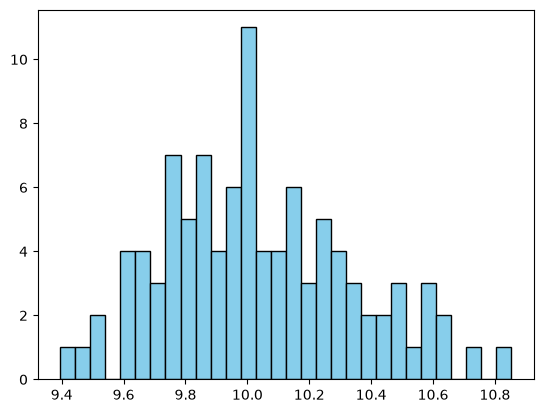

In [5]:
plt.hist(values, bins=30, color='skyblue', edgecolor='black')

# Multi Dimension Kelman Filtering


In [8]:
message_queue = WebSocketCollector(ws_url, max_messages=200).collect()
print("Collected messages:", message_queue.qsize())
raw_values = [message_queue.get() for _ in range(message_queue.qsize())]

WebSocket opened
WebSocket closed
WebSocket closed
Collected messages: 200


In [9]:
values = [json.loads(value).get("data") for value in raw_values][:-1]

print("Extracted values:", values[1])
grouped_values = {}

for value in values[0].get("sensors"):
    grouped_values[value.get("id")] = {
        'name': value.get("name"),
        'values': list()
    }

for value in values[1:]:
    grouped_values[value.get("sensor_id")]['values'].append(float(value.get("value")))

print("Grouped values:", grouped_values)

keys = list(grouped_values.keys())

vp_list = list(zip(grouped_values[keys[0]]['values'], grouped_values[keys[1]]['values']))

print("Velocity-Position pairs (first 10):", vp_list[:10])

Extracted values: {'sensor_id': '59e219b8-e38d-41c4-811a-d370c26ac176', 'value': 9.8697768422814, 'timestamp': '2026-06-15T01:24:59.106601'}
Grouped values: {'59e219b8-e38d-41c4-811a-d370c26ac176': {'name': 'Distance Sensor', 'values': [9.8697768422814, 9.707145628385707, 10.385385179461617, 9.815026097493764, 9.953552225685652, 9.708739735003038, 9.96513741450129, 10.309491006103178, 9.790619544314948, 9.496997259212307, 10.441008920010388, 10.13164538986685, 9.859888396988651, 9.543482690824804, 9.920508088821585, 9.881943982540394, 10.323690841934699, 9.535629835285842, 9.97822330371665, 9.934594746547452, 10.179962140187625, 10.209639375244748, 10.217009748443447, 10.177892899485093, 10.148739978065016, 9.853669170757147, 9.832233322959654, 10.269524601549573, 10.245152770696102, 10.05405819363025, 9.613787072613446, 10.321933775319915, 10.145909787659413, 10.360179741613976, 9.698695904216768, 9.83203435950803, 10.18008357733575, 9.660983388404965, 10.088444853470374, 9.6407796746

In [10]:


# Enhanced Kalman filter using class
if vp_list:
    # Use advanced Kalman filter with velocity estimation
    kf = KalmanFilter2D(dt=0.1,
                        x0=vp_list[0],
                        Q0=[1e-5, 1e-5], 
                        R0=[1e-2, 1e-2],
                        e0=[1.0, 1.0])
    
    filtered_values = kf.filter(vp_list)
    
    print("=== Kalman Filter Results ===")
    print(f"Raw values (first 10): {vp_list[:10]}")
    print(f"Filtered values (first 10): {[f'[P = {v[0]:.4f}, V = {v[1]:.4f}]' for v in filtered_values[:10]]}")

=== Kalman Filter Results ===
Raw values (first 10): [(9.8697768422814, 5.005771890210595), (9.707145628385707, 4.969920565380849), (10.385385179461617, 4.961363889523791), (9.815026097493764, 4.9260275149224695), (9.953552225685652, 5.021381019458432), (9.708739735003038, 5.024342817705418), (9.96513741450129, 5.102750441449396), (10.309491006103178, 5.07794349543367), (9.790619544314948, 5.056562523245192), (9.496997259212307, 5.027205947817421)]
Filtered values (first 10): ['[P = 9.8747, V = 4.5052]', '[P = 10.1499, V = 4.4099]', '[P = 10.9387, V = 4.7505]', '[P = 9.9682, V = 3.3357]', '[P = 11.6420, V = 4.6573]', '[P = 10.0539, V = 2.6369]', '[P = 12.4334, V = 4.7279]', '[P = 10.6420, V = 2.4894]', '[P = 12.3643, V = 3.9339]', '[P = 10.5732, V = 1.7868]']


(array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,  4.,  4.,
         9., 32., 12.,  5.,  3.,  3.,  2.,  2.,  1.,  1.,  2.,  1.,  0.,
         1.,  1.,  1.,  1.]),
 array([-202.97315722, -188.05597842, -173.13879961, -158.22162081,
        -143.304442  , -128.38726319, -113.47008439,  -98.55290558,
         -83.63572677,  -68.71854797,  -53.80136916,  -38.88419036,
         -23.96701155,   -9.04983274,    5.86734606,   20.78452487,
          35.70170367,   50.61888248,   65.53606129,   80.45324009,
          95.3704189 ,  110.2875977 ,  125.20477651,  140.12195532,
         155.03913412,  169.95631293,  184.87349174,  199.79067054,
         214.70784935,  229.62502815,  244.54220696]),
 <BarContainer object of 30 artists>)

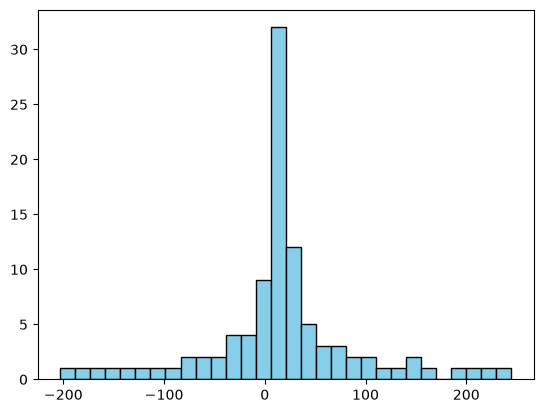

In [11]:
plt.hist([x[0] for x in filtered_values], bins=30, color='skyblue', edgecolor='black')

(array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,  4.,  4.,
         8., 28., 16.,  6.,  3.,  3.,  2.,  2.,  1.,  1.,  2.,  1.,  0.,
         1.,  1.,  1.,  1.]),
 array([-229.64696157, -213.96525935, -198.28355713, -182.60185492,
        -166.9201527 , -151.23845048, -135.55674827, -119.87504605,
        -104.19334383,  -88.51164162,  -72.8299394 ,  -57.14823718,
         -41.46653497,  -25.78483275,  -10.10313053,    5.57857168,
          21.2602739 ,   36.94197612,   52.62367833,   68.30538055,
          83.98708277,   99.66878498,  115.3504872 ,  131.03218942,
         146.71389163,  162.39559385,  178.07729607,  193.75899828,
         209.4407005 ,  225.12240272,  240.80410493]),
 <BarContainer object of 30 artists>)

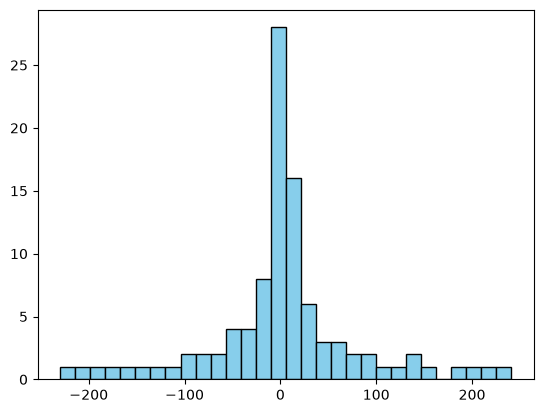

In [12]:
plt.hist([x[1] for x in filtered_values], bins=30, color='skyblue', edgecolor='black')